In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
# Data downloaded from https://www.upf.edu/web/ntsa/downloads/-/asset_publisher/xvT6E4pczrBw/content/2001-indications-of-nonlinear-deterministic-and-finite-dimensional-structures-in-time-series-of-brain-electrical-activity-dependence-on-recording-regi
# processing code from https://www.kaggle.com/code/a2m2a2n2/eeg2-0-multiclass

### Preparing the Data

In [26]:
df = pd.DataFrame()
dirs = ['S', 'F', 'N', 'O', 'Z']
for i in range(5):
    directory = f'{dirs[i]}'
    for filename in os.listdir(directory):
        temp_df = pd.read_csv(f'{directory}/{filename}', names = ['Values'])
        df = pd.concat([df, temp_df], axis = 1, ignore_index=True)

In [27]:
df = df.T

In [28]:
df

,0,1,2,3,4,5,6,7,8,9,...,4087,4088,4089,4090,4091,4092,4093,4094,4095,4096
0,661,721,702,628,519,394,308,226,145,64,...,460,419,324,189,78,7,5,12,29,-211
1,1,-47,-100,-192,-252,-277,-268,-216,-153,-111,...,147,235,253,209,142,102,82,77,78,-320
2,-18,-55,-126,-202,-238,-226,-171,-111,-73,-48,...,-59,-48,-94,-161,-210,-222,-224,-200,-127,-226
3,-458,-669,-914,-999,-846,-566,-323,4,0,-115,...,-1033,-1063,-740,-226,-5,301,475,356,87,215
4,213,210,210,212,194,162,121,84,45,11,...,-5,-2,1,1,-2,-8,-9,-2,20,-231
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,-10,-9,-33,-24,-61,-52,-41,-4,16,14,...,-7,-12,-5,-6,-5,-17,-37,-29,-18,-51
496,-31,-16,10,28,31,8,-21,-50,-67,-59,...,-15,-9,5,13,15,0,3,1,1,0
497,8,17,29,46,50,44,28,19,17,15,...,-20,-29,-34,-38,-43,-48,-50,-40,-36,7
498,-19,-39,-41,-16,5,14,6,-5,-20,-23,...,0,3,16,33,48,55,67,60,46,46


### Different Graphs for different Classes

<Axes: title={'center': 'EEG of Seizure Activity'}>

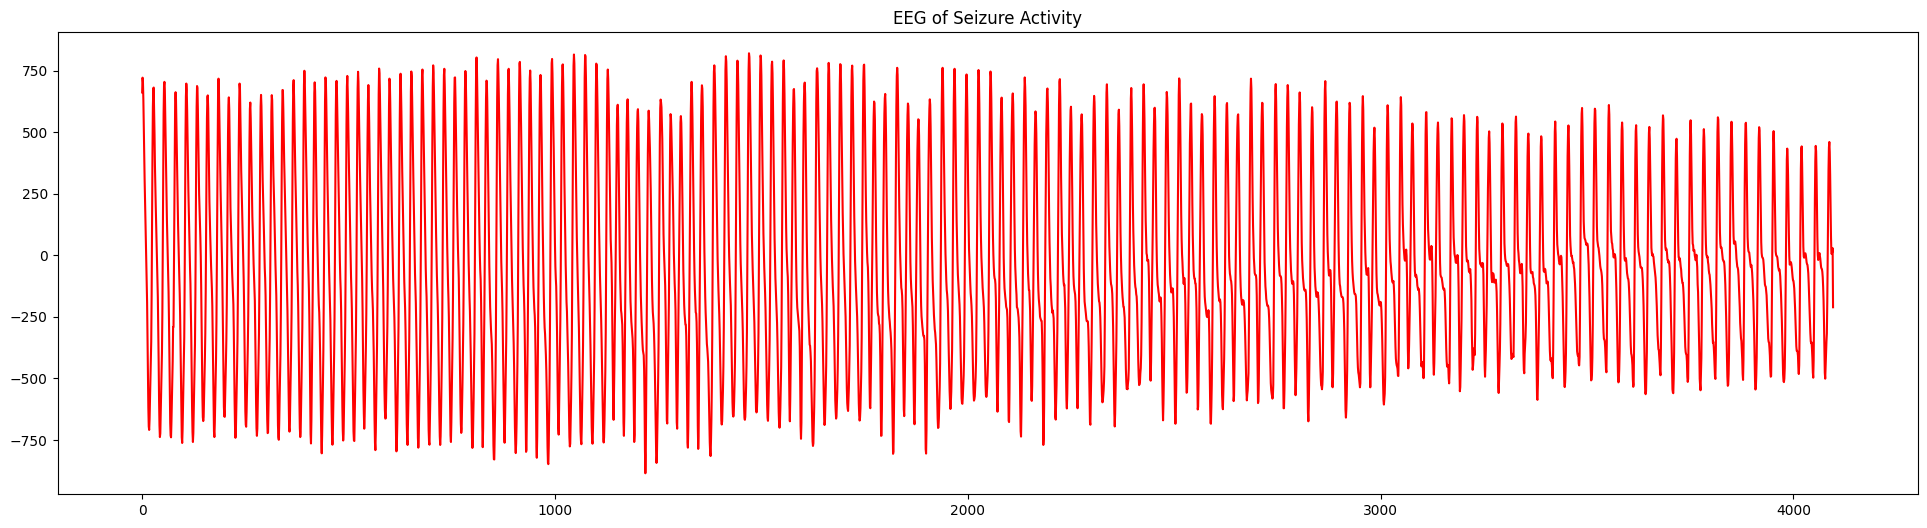

In [29]:
row1 = df.iloc[0, :]
row1.plot(figsize=(24,6), color = 'red', title = 'EEG of Seizure Activity')

<Axes: title={'center': 'EEG from location of Tumor'}>

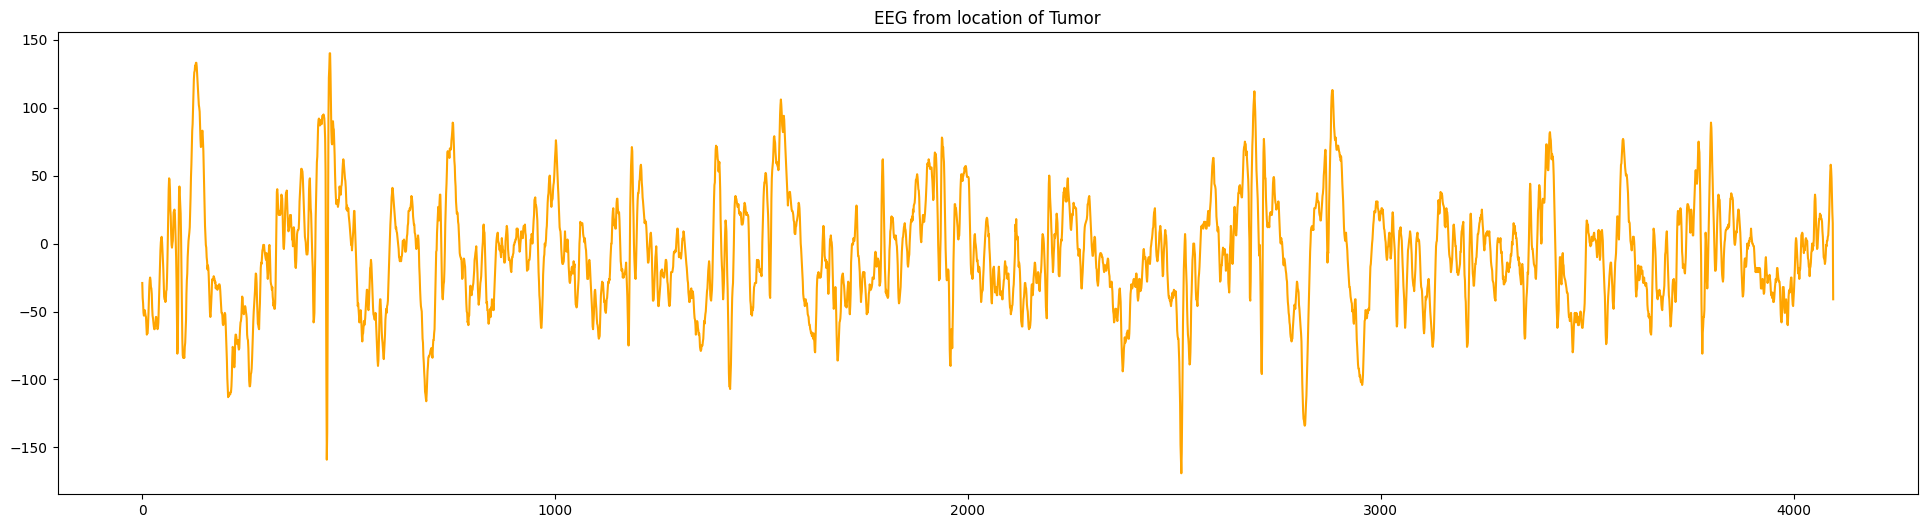

In [30]:
row2 = df.iloc[100, :]
row2.plot(figsize=(24,6), color = 'orange',  title = 'EEG from location of Tumor')

<Axes: title={'center': 'EEG from Healthy Part of the Brain'}>

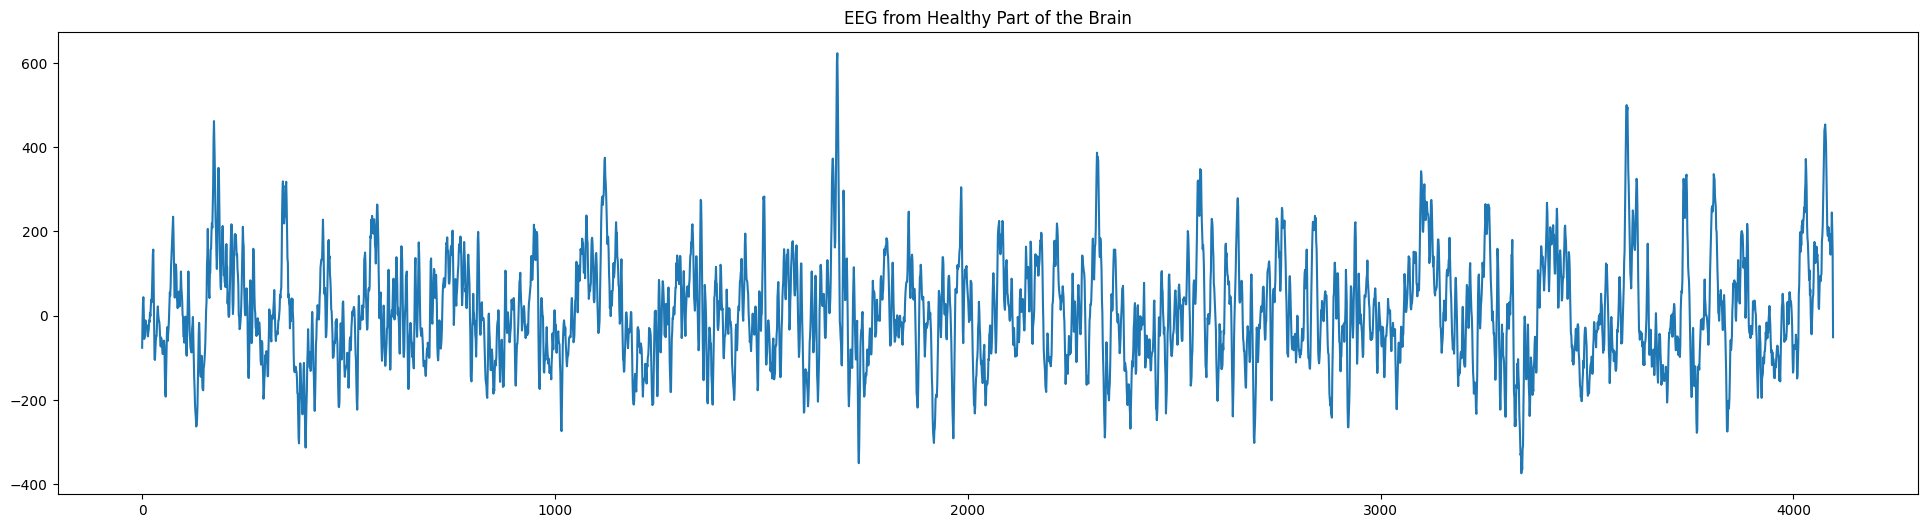

In [31]:
row3 = df.iloc[200, :]
row3.plot(figsize=(24,6), title = 'EEG from Healthy Part of the Brain')

<Axes: title={'center': 'EEG when Eyes closed'}>

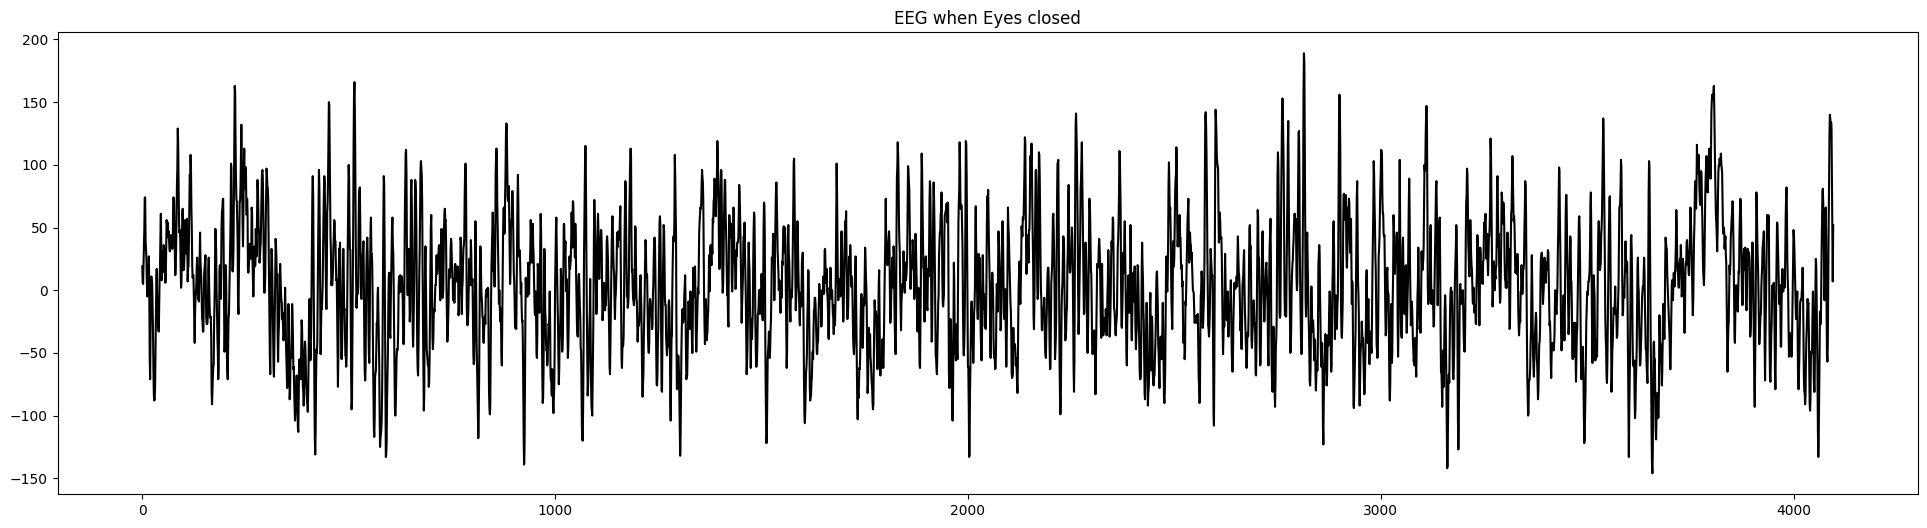

In [32]:
row4 = df.iloc[300, :]
row4.plot(figsize=(24,6), color = 'black', title = 'EEG when Eyes closed')

<Axes: title={'center': 'EEG when Eyes opened'}>

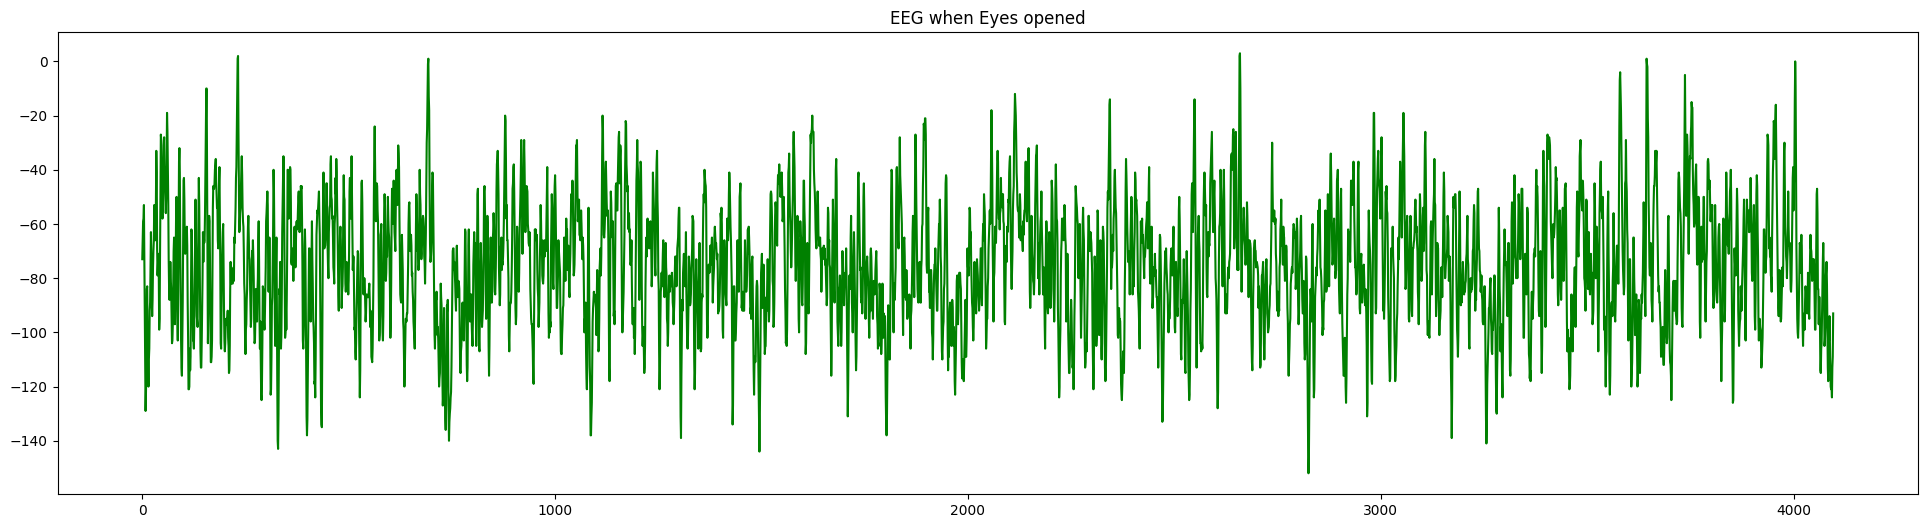

In [33]:
row5 = df.iloc[400, :]
row5.plot(figsize=(24,6), color = 'green',  title = 'EEG when Eyes opened')

### Adding labels to the DataFrame

In [34]:
labels = []
for i in range(5):
    for j in range(100):
        labels.append(i+1)

In [35]:
labels = pd.get_dummies(labels,  prefix = 'y')

In [36]:
labels

,y_1,y_2,y_3,y_4,y_5
0,True,False,False,False,False
1,True,False,False,False,False
2,True,False,False,False,False
3,True,False,False,False,False
4,True,False,False,False,False
...,...,...,...,...,...
495,False,False,False,False,True
496,False,False,False,False,True
497,False,False,False,False,True
498,False,False,False,False,True


In [37]:
df = pd.concat([df, labels], axis = 1)

In [38]:
df

,0,1,2,3,4,5,6,7,8,9,...,4092,4093,4094,4095,4096,y_1,y_2,y_3,y_4,y_5
0,661,721,702,628,519,394,308,226,145,64,...,7,5,12,29,-211,True,False,False,False,False
1,1,-47,-100,-192,-252,-277,-268,-216,-153,-111,...,102,82,77,78,-320,True,False,False,False,False
2,-18,-55,-126,-202,-238,-226,-171,-111,-73,-48,...,-222,-224,-200,-127,-226,True,False,False,False,False
3,-458,-669,-914,-999,-846,-566,-323,4,0,-115,...,301,475,356,87,215,True,False,False,False,False
4,213,210,210,212,194,162,121,84,45,11,...,-8,-9,-2,20,-231,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,-10,-9,-33,-24,-61,-52,-41,-4,16,14,...,-17,-37,-29,-18,-51,False,False,False,False,True
496,-31,-16,10,28,31,8,-21,-50,-67,-59,...,0,3,1,1,0,False,False,False,False,True
497,8,17,29,46,50,44,28,19,17,15,...,-48,-50,-40,-36,7,False,False,False,False,True
498,-19,-39,-41,-16,5,14,6,-5,-20,-23,...,55,67,60,46,46,False,False,False,False,True


In [18]:
df = df.sample(frac=1).reset_index(drop=True)

In [19]:
df

,0,1,2,3,4,5,6,7,8,9,...,4092,4093,4094,4095,4096,y_1,y_2,y_3,y_4,y_5
0,-37,-44,-48,-46,-45,-47,-47,-53,-58,-67,...,-17,-19,-23,-21,25,False,False,True,False,False
1,-8,-19,-32,-40,-55,-60,-60,-59,-46,-25,...,65,40,27,41,-21,False,False,False,False,True
2,43,59,69,73,65,39,-1,-42,-73,-97,...,-66,-31,27,69,105,True,False,False,False,False
3,-16,-16,-20,-17,-19,-14,-11,-5,-5,-6,...,13,10,7,3,-20,False,True,False,False,False
4,-54,-74,-89,-106,-111,-104,-88,-64,-59,-48,...,69,72,27,-56,-136,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,29,-68,-143,-208,-307,-443,-470,-443,-329,-216,...,213,176,135,81,194,True,False,False,False,False
496,96,99,77,77,75,71,67,72,75,61,...,-162,-132,-85,-48,22,False,False,False,True,False
497,-1,-11,-11,-21,-32,-19,-2,15,28,45,...,-78,-47,-31,-31,-111,False,False,False,False,True
498,-41,-35,-28,-23,-20,-22,-28,-33,-30,-31,...,8,8,2,-7,28,False,False,True,False,False


In [20]:
df.duplicated().sum()

np.int64(0)

In [21]:
X = df.iloc[:, :-5]
Y = df.iloc[:, -5:]

### Imports for the Model

In [22]:
from keras.models import load_model
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM, Bidirectional
from sklearn.preprocessing import StandardScaler

ModuleNotFoundError: No module named 'keras'

### Scaling the input Data

In [20]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
Y = np.array(Y)

In [21]:
X.shape

(500, 4097)

In [22]:
Y.shape

(500, 5)

### Train-Test Split

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.3, random_state=0)

### Reshaping the inputs for LSTM Model

In [24]:
X_train = X_train.reshape(350, 4097, 1)
X_test = X_test.reshape(150, 4097, 1)

### Function to plot **Loss** and **Accuracy** Vs **Epochs**

In [25]:
import matplotlib.pyplot as plt
def plot_history(history):
    loss_list = [s for s in history.history.keys() if 'loss' in s and 'val' not in s]
    val_loss_list = [s for s in history.history.keys() if 'loss' in s and 'val' in s]
    acc_list = [s for s in history.history.keys() if 'acc' in s and 'val' not in s]
    val_acc_list = [s for s in history.history.keys() if 'acc' in s and 'val' in s]
    
    if len(loss_list) == 0:
        print('Loss is missing in history')
        return 
    
    ## As loss always exists
    epochs = range(1,len(history.history[loss_list[0]]) + 1)
    
    ## Loss
    plt.figure(1)
    for l in loss_list:
        plt.plot(epochs, history.history[l], 'b', label='Training loss (' + str(str(format(history.history[l][-1],'.5f'))+')'))
    for l in val_loss_list:
        plt.plot(epochs, history.history[l], 'g', label='Validation loss (' + str(str(format(history.history[l][-1],'.5f'))+')'))
    
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    
    ## Accuracy
    plt.figure(2)
    for l in acc_list:
        plt.plot(epochs, history.history[l], 'b', label='Training accuracy (' + str(format(history.history[l][-1],'.5f'))+')')
    for l in val_acc_list:    
        plt.plot(epochs, history.history[l], 'g', label='Validation accuracy (' + str(format(history.history[l][-1],'.5f'))+')')

    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

### Model 1 : **Vanilla LSTM**

In [26]:
model1 = Sequential()
model1.add(LSTM(200, input_shape = (4097, 1)))
model1.add(Dense(5, activation = 'softmax'))
model1.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist1 = model1.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 50, batch_size=16, verbose=2)
model1.summary()

2023-01-24 13:31:53.954545: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-24 13:31:54.063129: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-24 13:31:54.063968: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:937] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-24 13:31:54.066809: I tensorflow/core/platform/cpu_feature_guard.cc:142] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compil

Epoch 1/50


2023-01-24 13:31:59.223709: I tensorflow/stream_executor/cuda/cuda_dnn.cc:369] Loaded cuDNN version 8005


22/22 - 9s - loss: 1.5988 - accuracy: 0.2571 - val_loss: 1.3551 - val_accuracy: 0.3400
Epoch 2/50
22/22 - 5s - loss: 1.4542 - accuracy: 0.3686 - val_loss: 1.4413 - val_accuracy: 0.4067
Epoch 3/50
22/22 - 5s - loss: 1.3543 - accuracy: 0.3829 - val_loss: 1.3042 - val_accuracy: 0.4000
Epoch 4/50
22/22 - 5s - loss: 1.3392 - accuracy: 0.3657 - val_loss: 1.3349 - val_accuracy: 0.3667
Epoch 5/50
22/22 - 5s - loss: 1.2975 - accuracy: 0.3829 - val_loss: 1.3136 - val_accuracy: 0.3600
Epoch 6/50
22/22 - 5s - loss: 1.2740 - accuracy: 0.3914 - val_loss: 1.2882 - val_accuracy: 0.3533
Epoch 7/50
22/22 - 5s - loss: 1.2537 - accuracy: 0.3771 - val_loss: 1.2679 - val_accuracy: 0.3867
Epoch 8/50
22/22 - 5s - loss: 1.2448 - accuracy: 0.4000 - val_loss: 1.2217 - val_accuracy: 0.3800
Epoch 9/50
22/22 - 5s - loss: 1.5971 - accuracy: 0.3771 - val_loss: 4.5140 - val_accuracy: 0.2267
Epoch 10/50
22/22 - 5s - loss: 2.8761 - accuracy: 0.1857 - val_loss: 1.7927 - val_accuracy: 0.1800
Epoch 11/50
22/22 - 5s - loss:

#### Accuracy and Loss Plot : **Vanilla LSTM**

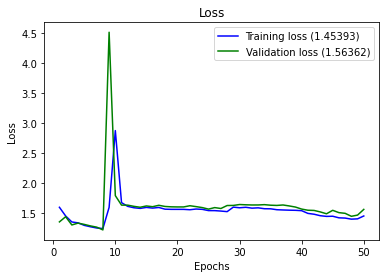

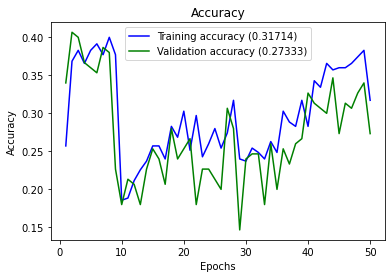

In [27]:
plot_history(hist1)

### Model 2 : **Stacked LSTM**

In [28]:
model2 = Sequential()
model2.add(LSTM(200, return_sequences=True, input_shape = (4097, 1)))
model2.add(LSTM(200))
model2.add(Dense(5, activation = 'softmax'))
model2.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist2 = model2.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 50, batch_size=16, verbose=2)
model2.summary()

Epoch 1/50
22/22 - 13s - loss: 1.4267 - accuracy: 0.2971 - val_loss: 1.3195 - val_accuracy: 0.3667
Epoch 2/50
22/22 - 10s - loss: 1.3159 - accuracy: 0.3400 - val_loss: 1.2209 - val_accuracy: 0.4133
Epoch 3/50
22/22 - 10s - loss: 1.4331 - accuracy: 0.3486 - val_loss: 1.4113 - val_accuracy: 0.3400
Epoch 4/50
22/22 - 10s - loss: 1.3716 - accuracy: 0.3171 - val_loss: 1.2013 - val_accuracy: 0.4133
Epoch 5/50
22/22 - 10s - loss: 1.2527 - accuracy: 0.4000 - val_loss: 1.2105 - val_accuracy: 0.3933
Epoch 6/50
22/22 - 10s - loss: 1.2376 - accuracy: 0.3971 - val_loss: 1.2072 - val_accuracy: 0.3600
Epoch 7/50
22/22 - 10s - loss: 1.2127 - accuracy: 0.3914 - val_loss: 1.2358 - val_accuracy: 0.3867
Epoch 8/50
22/22 - 10s - loss: 1.2355 - accuracy: 0.3886 - val_loss: 1.1949 - val_accuracy: 0.3733
Epoch 9/50
22/22 - 11s - loss: 1.2834 - accuracy: 0.3800 - val_loss: 1.3053 - val_accuracy: 0.3800
Epoch 10/50
22/22 - 10s - loss: 1.3769 - accuracy: 0.3829 - val_loss: 1.2815 - val_accuracy: 0.3600
Epoch 11/

#### Accuracy and Loss Plot : **Stacked LSTM**

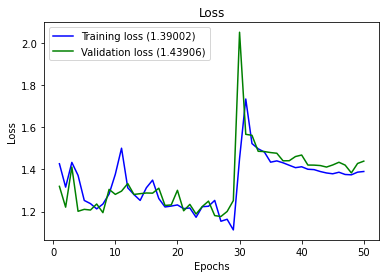

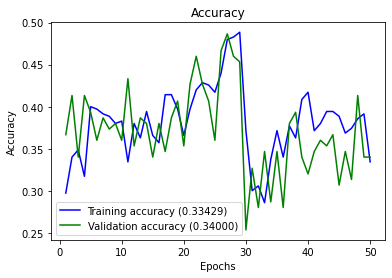

In [29]:
plot_history(hist2)

### Model 3 : **Bi-Directional LSTM**

In [30]:
model3 = Sequential()
model3.add(Bidirectional(LSTM(400)))
model3.add(Dense(5, activation = 'softmax'))
model3.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
hist3 = model3.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 50, batch_size=16, verbose=2)
model3.summary()

Epoch 1/50
22/22 - 20s - loss: 1.5425 - accuracy: 0.2886 - val_loss: 1.3138 - val_accuracy: 0.3400
Epoch 2/50
22/22 - 16s - loss: 1.3310 - accuracy: 0.3714 - val_loss: 1.3066 - val_accuracy: 0.4267
Epoch 3/50
22/22 - 16s - loss: 1.3521 - accuracy: 0.3800 - val_loss: 1.2662 - val_accuracy: 0.4267
Epoch 4/50
22/22 - 16s - loss: 1.3722 - accuracy: 0.3600 - val_loss: 1.4773 - val_accuracy: 0.3000
Epoch 5/50
22/22 - 16s - loss: 1.3313 - accuracy: 0.3686 - val_loss: 1.3445 - val_accuracy: 0.3267
Epoch 6/50
22/22 - 16s - loss: 1.2651 - accuracy: 0.3943 - val_loss: 1.2644 - val_accuracy: 0.4600
Epoch 7/50
22/22 - 16s - loss: 1.2112 - accuracy: 0.4229 - val_loss: 1.2093 - val_accuracy: 0.4000
Epoch 8/50
22/22 - 16s - loss: 1.2060 - accuracy: 0.3857 - val_loss: 1.2582 - val_accuracy: 0.3667
Epoch 9/50
22/22 - 16s - loss: 1.1818 - accuracy: 0.4171 - val_loss: 1.2144 - val_accuracy: 0.4800
Epoch 10/50
22/22 - 16s - loss: 1.3033 - accuracy: 0.3943 - val_loss: 1.4573 - val_accuracy: 0.2933
Epoch 11/

#### Accuracy and Loss Plot : **Bi-Directional LSTM**

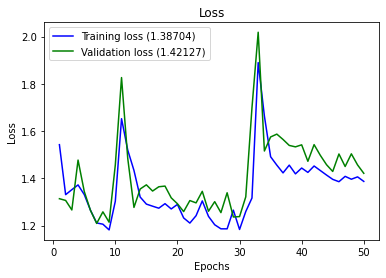

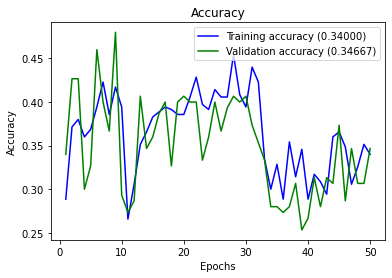

In [31]:
plot_history(hist3)

### Plotting **Confusion Matrix**

In [32]:
from sklearn import metrics

actual = np.argmax(y_test, axis=1)
predicted1 = np.argmax(model1.predict(X_test), axis=1)
predicted2 = np.argmax(model2.predict(X_test), axis=1)
predicted3 = np.argmax(model3.predict(X_test), axis=1)

confusion_matrix1 = metrics.confusion_matrix(actual, predicted1)
confusion_matrix2 = metrics.confusion_matrix(actual, predicted2)
confusion_matrix3 = metrics.confusion_matrix(actual, predicted3)

In [33]:
cm1_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix1, display_labels = ['A', 'B', 'C', 'D', 'E'])
cm2_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix2, display_labels = ['A', 'B', 'C', 'D', 'E'])
cm3_display = metrics.ConfusionMatrixDisplay(confusion_matrix = confusion_matrix3, display_labels = ['A', 'B', 'C', 'D', 'E'])

### Confusion Matrix : **Vanilla LSTM**

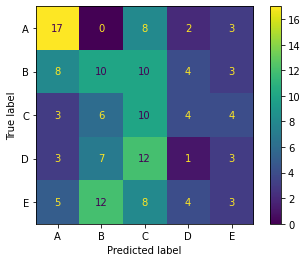

In [34]:
cm1_display.plot()
plt.show()

### Confusion Matrix : **Stacked LSTM**

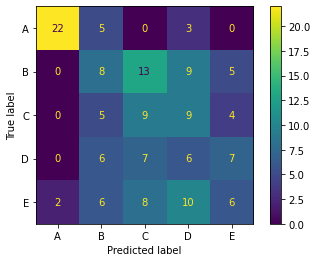

In [35]:
cm2_display.plot()
plt.show()

### Confusion Matrix : **Bi-Directional LSTM**

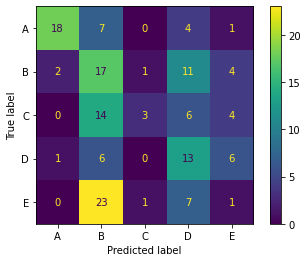

In [36]:
cm3_display.plot()
plt.show()